I0000 00:00:1778169262.169718   11513 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1778169262.762154   11513 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778169264.382674   11513 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


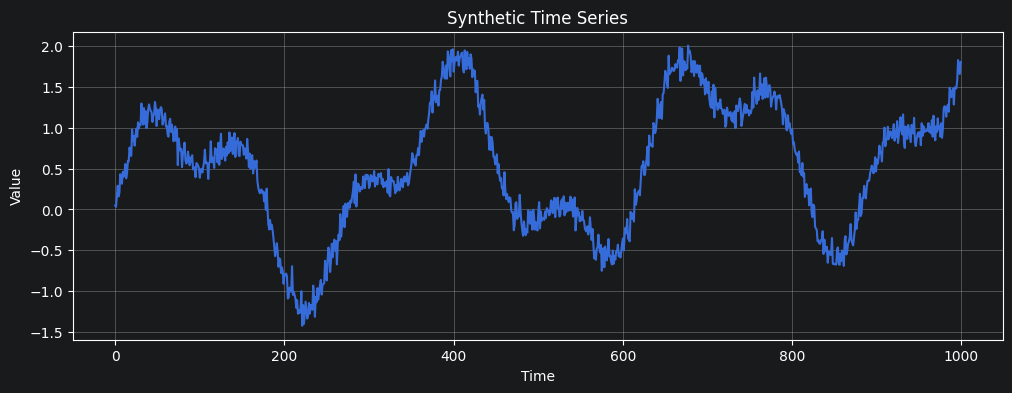

X_train: (770, 30, 1)
y_train: (770, 7)

Training Recursive model...
Epoch 1/10


E0000 00:00:1778169265.194507   11513 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1778169265.219692   11513 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...
/home/wojtek/PycharmProjects/my_first_ds_project/.venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2202
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0145
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0072
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0052
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0042
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0038
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0036
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0034
Epoch 9/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0032
Epoch 10/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0030

Training Direct models...

Training Multi-output model...
Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2952
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0536
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0091
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0065
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 

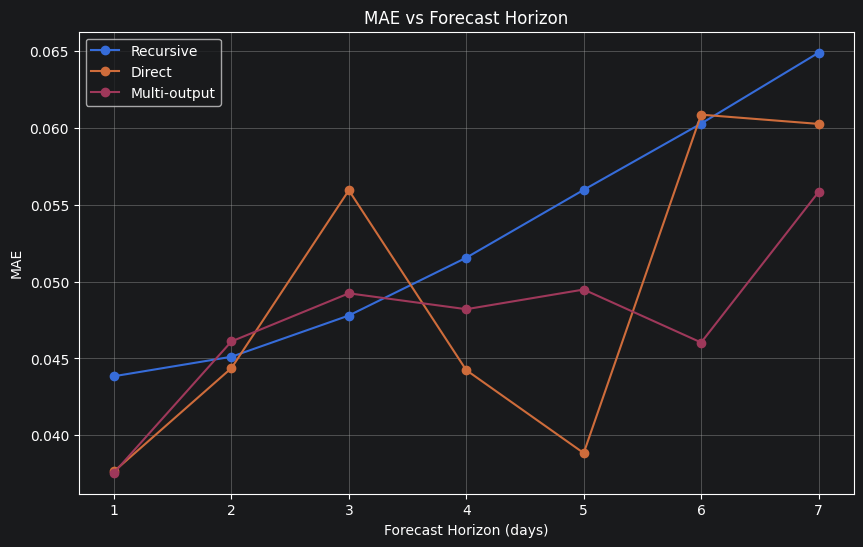

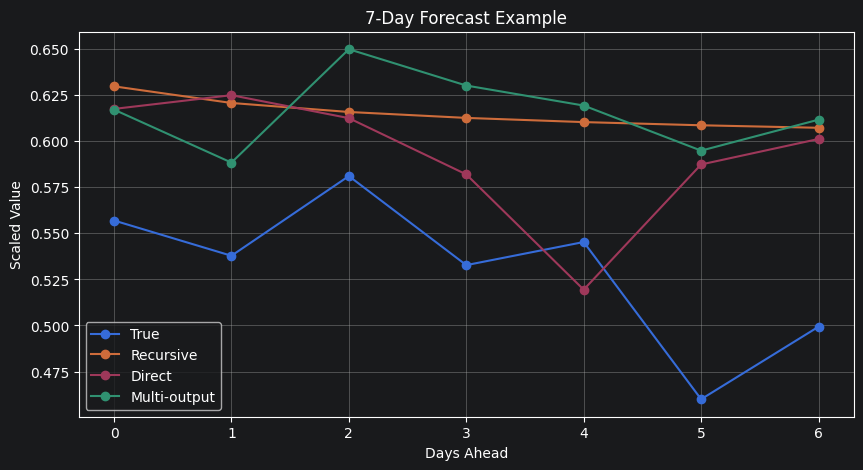

In [1]:
# Zadanie 11 - Multi-step forecast
"""
Zbuduj model prognozujący 7 dni naraz (zamiast 1 dnia):
Podejście 1: Recursive (prognozuj 1 dzień, użyj jako wejście)
Podejście 2: Direct (osobny model na każdy dzień)
Podejście 3: LSTM z Dense(7) na wyjściu

Porównaj błędy per horyzont (dzień 1 vs dzień 7).

Oczekiwany wynik: porównanie 3 podejść, błąd vs horyzont
"""

import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# GENEROWANIE SZEREGU CZASOWEGO
np.random.seed(42)

t = np.arange(0, 1000)

series = (
    np.sin(0.02 * t)
    + 0.5 * np.sin(0.05 * t)
    + 0.001 * t
    + np.random.normal(scale=0.1, size=len(t))
)

plt.figure(figsize=(12,4))
plt.plot(series)
plt.title("Synthetic Time Series")
plt.xlabel("Time")
plt.ylabel("Value")
plt.grid()
plt.show()

# SCALING
scaler = MinMaxScaler()

series_scaled = scaler.fit_transform(
    series.reshape(-1,1)
)

# CREATE SEQUENCES
WINDOW = 30
HORIZON = 7

def create_sequences(data, window, horizon):

    X = []
    y = []

    for i in range(len(data) - window - horizon):

        X.append(data[i:i+window])

        y.append(
            data[i+window:i+window+horizon].flatten()
        )

    return np.array(X), np.array(y)

X, y = create_sequences(
    series_scaled,
    WINDOW,
    HORIZON
)

# TRAIN / TEST

split = int(0.8 * len(X))

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

# APPROACH 1 -- RECURSIVE
print("\nTraining Recursive model...")

recursive_model = Sequential([
    LSTM(32, input_shape=(WINDOW,1)),
    Dense(1)
])

recursive_model.compile(
    optimizer="adam",
    loss="mse"
)

recursive_model.fit(
    X_train,
    y_train[:,0],   # tylko 1 dzień
    epochs=10,
    batch_size=32,
    verbose=1
)

# Recursive forecasting
recursive_preds = []

for sample in X_test:

    current_window = sample.copy()

    preds = []

    for _ in range(HORIZON):

        pred = recursive_model.predict(
            current_window.reshape(1, WINDOW, 1),
            verbose=0
        )[0,0]

        preds.append(pred)

        # shift window
        current_window = np.roll(
            current_window,
            -1
        )

        current_window[-1] = pred

    recursive_preds.append(preds)

recursive_preds = np.array(recursive_preds)

# APPROACH 2 -- DIRECT
print("\nTraining Direct models...")

direct_models = []

for h in range(HORIZON):

    model = Sequential([
        LSTM(32, input_shape=(WINDOW,1)),
        Dense(1)
    ])

    model.compile(
        optimizer="adam",
        loss="mse"
    )

    model.fit(
        X_train,
        y_train[:,h],
        epochs=10,
        batch_size=32,
        verbose=0
    )

    direct_models.append(model)

# Direct predictions
direct_preds = []

for h in range(HORIZON):

    pred = direct_models[h].predict(
        X_test,
        verbose=0
    ).flatten()

    direct_preds.append(pred)

direct_preds = np.array(direct_preds).T

# APPROACH 3 -- MULTI OUTPUT
print("\nTraining Multi-output model...")

multi_model = Sequential([
    LSTM(32, input_shape=(WINDOW,1)),
    Dense(HORIZON)
])

multi_model.compile(
    optimizer="adam",
    loss="mse"
)

multi_model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    verbose=1
)

multi_preds = multi_model.predict(
    X_test,
    verbose=0
)

# MAE PER HORIZON
recursive_mae = []
direct_mae = []
multi_mae = []

for h in range(HORIZON):

    recursive_mae.append(
        mean_absolute_error(
            y_test[:,h],
            recursive_preds[:,h]
        )
    )

    direct_mae.append(
        mean_absolute_error(
            y_test[:,h],
            direct_preds[:,h]
        )
    )

    multi_mae.append(
        mean_absolute_error(
            y_test[:,h],
            multi_preds[:,h]
        )
    )

# TABELA WYNIKÓW
print("\n=== MAE PER HORIZON ===")

print("\nDay | Recursive | Direct | Multi-output")

for h in range(HORIZON):

    print(
        f"{h+1:>3} | "
        f"{recursive_mae[h]:.4f} | "
        f"{direct_mae[h]:.4f} | "
        f"{multi_mae[h]:.4f}"
    )

# WYKRES MAE vs HORIZON
days = np.arange(1, HORIZON+1)

plt.figure(figsize=(10,6))

plt.plot(days, recursive_mae, marker='o', label="Recursive")
plt.plot(days, direct_mae, marker='o', label="Direct")
plt.plot(days, multi_mae, marker='o', label="Multi-output")

plt.xlabel("Forecast Horizon (days)")
plt.ylabel("MAE")
plt.title("MAE vs Forecast Horizon")

plt.xticks(days)

plt.grid()
plt.legend()

plt.show()

# WIZUALIZACJA PRZYKŁADOWEJ PROGNOZY
idx = 10

plt.figure(figsize=(10,5))

plt.plot(
    range(HORIZON),
    y_test[idx],
    marker='o',
    label="True"
)

plt.plot(
    range(HORIZON),
    recursive_preds[idx],
    marker='o',
    label="Recursive"
)

plt.plot(
    range(HORIZON),
    direct_preds[idx],
    marker='o',
    label="Direct"
)

plt.plot(
    range(HORIZON),
    multi_preds[idx],
    marker='o',
    label="Multi-output"
)

plt.xlabel("Days Ahead")
plt.ylabel("Scaled Value")

plt.title("7-Day Forecast Example")

plt.legend()
plt.grid()

plt.show()